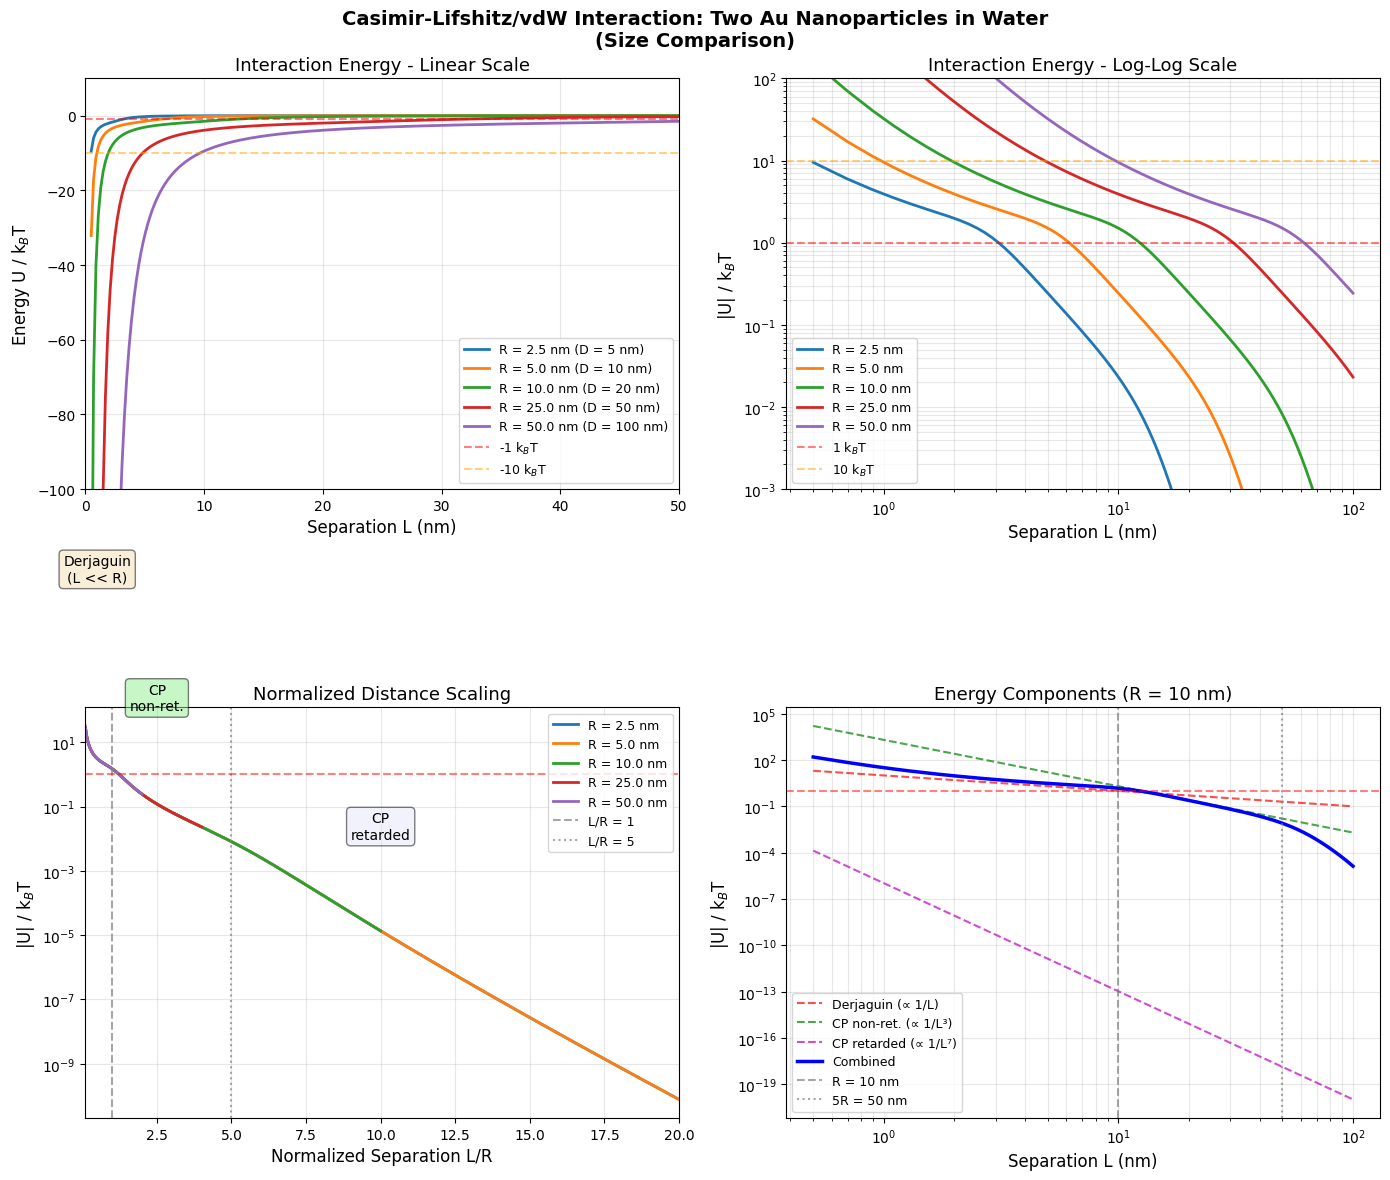

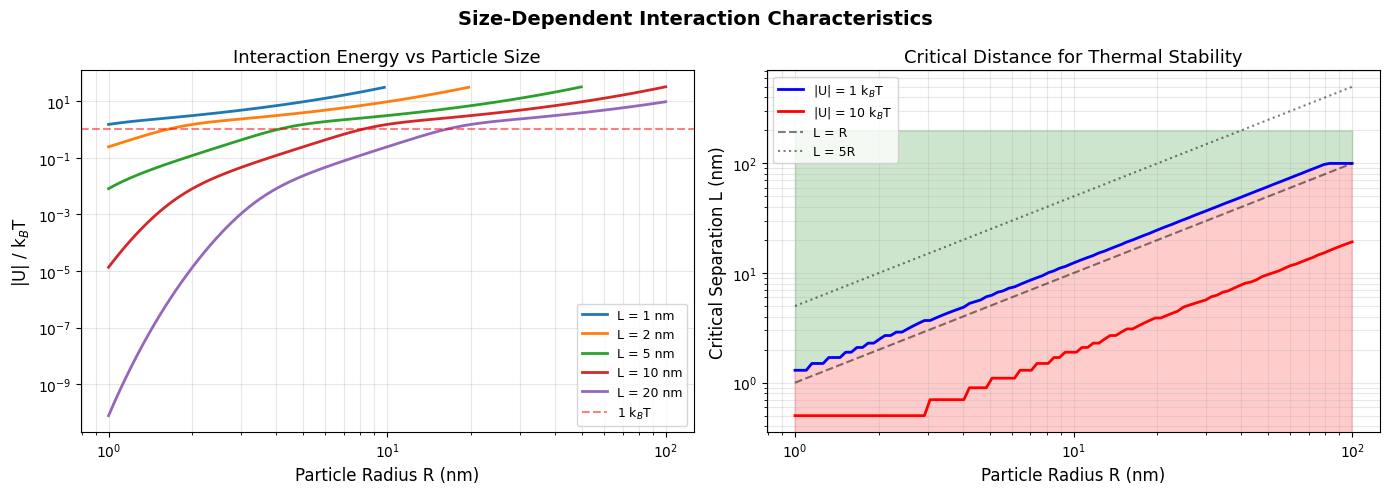


SPHERE-SPHERE INTERACTION SUMMARY: SIZE COMPARISON
Hamaker constant A_H: 5.0 × 10⁻²⁰ J
Temperature: 298 K
Medium: Water (ε = 78.5)

R (nm)     D (nm)     U at 1nm     U at 5nm     U at 10nm    L(1kT)      
                      (kT)         (kT)         (kT)         (nm)        
--------------------------------------------------------------------------------
2.5        5          -3.95        -0.24        -0.023       3.1         
5.0        10         -9.71        -1.50        -0.243       6.1         
10.0       20         -33.27       -3.09        -1.502       12.3        
25.0       50         -296.27      -9.50        -3.900       30.8        
50.0       100        -2018.92     -32.16       -9.495       61.7        
500.0      1000       -1805372.64  -14289.77    -1910.755    100.0       

SCALING BEHAVIOR ANALYSIS

Regime          | Distance Range | Energy Scaling | R Dependence
----------------|----------------|----------------|---------------
Derjaguin       | L << R         |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
R_sizes = [2.5e-9, 5e-9, 10e-9, 25e-9, 50e-9, 500e-9]  # Different particle radii (m)
A_H = 5e-20              # Hamaker constant for Au-water-Au (J)
kB = 1.38e-23            # Boltzmann constant (J/K)
T = 298                  # Temperature (K)
L_values = np.linspace(0.5e-9, 100e-9, 500)  # Separation distances (m)

# Physical constants
hbar = 1.054e-34  # J*s
c = 3e8           # m/s
eps0 = 8.854e-12  # F/m
eps_m = 78.5      # Relative permittivity of water

# Colors for different sizes
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# -----------------------------
# Functions
# -----------------------------
def U_vdW_derjaguin(L, R):
    """Near-field Derjaguin / non-retarded vdW (R >> L)"""
    R_eff = R / 2  # For identical spheres
    return -A_H * R_eff / (6 * L)

def U_CP_nonretarded(L, R):
    """Non-retarded Casimir-Polder, small particle limit (R << L)"""
    return -A_H * R**3 / (6 * L**3)

def U_CP_retarded(L, R):
    """Retarded Casimir-Polder, far-field (1/L^7)"""
    alpha = 4 * np.pi * eps0 * eps_m * R**3
    return -23 * hbar * c * alpha**2 / (4 * np.pi * L**7)

def smooth_transition(L, L_trans, width):
    """Smooth sigmoid transition function"""
    return 1 / (1 + np.exp(-(L - L_trans) / width))

def compute_total_energy(L_array, R):
    """Compute total interaction energy with smooth transitions"""
    U_derj = np.array([U_vdW_derjaguin(L, R) for L in L_array])
    U_nr = np.array([U_CP_nonretarded(L, R) for L in L_array])
    U_ret = np.array([U_CP_retarded(L, R) for L in L_array])
    
    # Transition points scale with particle size
    trans1 = smooth_transition(L_array, R, R/5)
    trans2 = smooth_transition(L_array, 5*R, R)
    
    # Combined potential
    U_total = (1 - trans1) * U_derj + \
              trans1 * (1 - trans2) * U_nr + \
              trans2 * U_ret
    
    return U_total, U_derj, U_nr, U_ret

# -----------------------------
# Compute energies for all sizes
# -----------------------------
results = {}
for R in R_sizes:
    U_total, U_derj, U_nr, U_ret = compute_total_energy(L_values, R)
    results[R] = {
        'total': U_total,
        'derjaguin': U_derj,
        'cp_nr': U_nr,
        'cp_ret': U_ret,
        'total_kBT': U_total / (kB * T)
    }

# -----------------------------
# Plot - Four panel figure
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Panel 1: Linear scale comparison
ax1 = axes[0, 0]
for R, color in zip(R_sizes, colors):
    ax1.plot(L_values*1e9, results[R]['total_kBT'], '-', linewidth=2, 
             color=color, label=f'R = {R*1e9:.1f} nm (D = {2*R*1e9:.0f} nm)')
ax1.axhline(-1, color='red', linestyle='--', alpha=0.5, label='-1 k$_B$T')
ax1.axhline(-10, color='orange', linestyle='--', alpha=0.5, label='-10 k$_B$T')
ax1.set_xlabel('Separation L (nm)', fontsize=12)
ax1.set_ylabel('Energy U / k$_B$T', fontsize=12)
ax1.set_title('Interaction Energy - Linear Scale', fontsize=13)
ax1.set_ylim([-100, 10])
ax1.set_xlim([0, 50])
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right', fontsize=9)

# Panel 2: Log-log scale comparison
ax2 = axes[0, 1]
for R, color in zip(R_sizes, colors):
    ax2.loglog(L_values*1e9, np.abs(results[R]['total_kBT']), '-', linewidth=2, 
               color=color, label=f'R = {R*1e9:.1f} nm')
ax2.axhline(1, color='red', linestyle='--', alpha=0.5, label='1 k$_B$T')
ax2.axhline(10, color='orange', linestyle='--', alpha=0.5, label='10 k$_B$T')
ax2.set_xlabel('Separation L (nm)', fontsize=12)
ax2.set_ylabel('|U| / k$_B$T', fontsize=12)
ax2.set_ylim((1e-3,1e6))
ax2.set_title('Interaction Energy - Log-Log Scale', fontsize=13)
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(loc='lower left', fontsize=9)

# Panel 3: Normalized separation (L/R)
ax3 = axes[1, 0]
for R, color in zip(R_sizes, colors):
    L_norm = L_values / R
    # Only plot where L/R is reasonable
    mask = (L_norm >= 0.1) & (L_norm <= 20)
    ax3.semilogy(L_norm[mask], np.abs(results[R]['total_kBT'][mask]), '-', 
                 linewidth=2, color=color, label=f'R = {R*1e9:.1f} nm')

# Add regime boundaries
ax3.axvline(1, color='gray', linestyle='--', alpha=0.7, label='L/R = 1')
ax3.axvline(5, color='gray', linestyle=':', alpha=0.7, label='L/R = 5')
ax3.axhline(1, color='red', linestyle='--', alpha=0.5)
ax3.set_xlabel('Normalized Separation L/R', fontsize=12)
ax3.set_ylabel('|U| / k$_B$T', fontsize=12)
ax3.set_title('Normalized Distance Scaling', fontsize=13)
ax3.set_xlim([0.1, 20])
ax3.grid(True, alpha=0.3, which='both')
ax3.legend(loc='upper right', fontsize=9)

# Add regime labels
ax3.text(0.5, 1e6, 'Derjaguin\n(L << R)', fontsize=10, ha='center', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax3.text(2.5, 1e2, 'CP\nnon-ret.', fontsize=10, ha='center',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax3.text(10, 1e-2, 'CP\nretarded', fontsize=10, ha='center',
         bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))

# Panel 4: Components for one representative size (R = 10 nm)
ax4 = axes[1, 1]
R_rep = 10e-9  # Representative size
U_total, U_derj, U_nr, U_ret = compute_total_energy(L_values, R_rep)

ax4.loglog(L_values*1e9, np.abs(U_derj)/(kB*T), 'r--', linewidth=1.5, 
           alpha=0.7, label='Derjaguin (∝ 1/L)')
ax4.loglog(L_values*1e9, np.abs(U_nr)/(kB*T), 'g--', linewidth=1.5, 
           alpha=0.7, label='CP non-ret. (∝ 1/L³)')
ax4.loglog(L_values*1e9, np.abs(U_ret)/(kB*T), 'm--', linewidth=1.5, 
           alpha=0.7, label='CP retarded (∝ 1/L⁷)')
ax4.loglog(L_values*1e9, np.abs(U_total)/(kB*T), 'b-', linewidth=2.5, 
           label='Combined')
ax4.axvline(R_rep*1e9, color='gray', linestyle='--', alpha=0.7, label=f'R = {R_rep*1e9:.0f} nm')
ax4.axvline(5*R_rep*1e9, color='gray', linestyle=':', alpha=0.7, label=f'5R = {5*R_rep*1e9:.0f} nm')
ax4.axhline(1, color='red', linestyle='--', alpha=0.5)
ax4.set_xlabel('Separation L (nm)', fontsize=12)
ax4.set_ylabel('|U| / k$_B$T', fontsize=12)
ax4.set_title(f'Energy Components (R = {R_rep*1e9:.0f} nm)', fontsize=13)
ax4.grid(True, alpha=0.3, which='both')
ax4.legend(loc='lower left', fontsize=9)

plt.suptitle('Casimir-Lifshitz/vdW Interaction: Two Au Nanoparticles in Water\n(Size Comparison)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nanoparticle_size_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------
# Additional Plot: Energy at fixed separation vs particle size
# -----------------------------
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Create finer R array for smooth curves
R_fine = np.logspace(np.log10(1e-9), np.log10(100e-9), 100)
L_fixed_values = [1e-9, 2e-9, 5e-9, 10e-9, 20e-9]
colors_L = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Panel 1: Energy vs R at fixed L
ax2_1 = axes2[0]
for L_fixed, color in zip(L_fixed_values, colors_L):
    U_vs_R = []
    for R in R_fine:
        if L_fixed < 0.1 * R:  # Avoid unphysical regime
            U_vs_R.append(np.nan)
        else:
            U_total, _, _, _ = compute_total_energy(np.array([L_fixed]), R)
            U_vs_R.append(np.abs(U_total[0]) / (kB * T))
    ax2_1.loglog(R_fine*1e9, U_vs_R, '-', linewidth=2, color=color, 
                 label=f'L = {L_fixed*1e9:.0f} nm')

ax2_1.axhline(1, color='red', linestyle='--', alpha=0.5, label='1 k$_B$T')
ax2_1.set_xlabel('Particle Radius R (nm)', fontsize=12)
ax2_1.set_ylabel('|U| / k$_B$T', fontsize=12)
ax2_1.set_title('Interaction Energy vs Particle Size', fontsize=13)
ax2_1.grid(True, alpha=0.3, which='both')
ax2_1.legend(loc='lower right', fontsize=9)

# Panel 2: Critical separation (where U = 1 kT) vs R
ax2_2 = axes2[1]
L_crit_1kT = []
L_crit_10kT = []

for R in R_fine:
    U_total, _, _, _ = compute_total_energy(L_values, R)
    U_kBT = np.abs(U_total) / (kB * T)
    
    # Find where |U| = 1 kT
    idx_1kT = np.argmin(np.abs(U_kBT - 1))
    L_crit_1kT.append(L_values[idx_1kT] * 1e9)
    
    # Find where |U| = 10 kT
    idx_10kT = np.argmin(np.abs(U_kBT - 10))
    L_crit_10kT.append(L_values[idx_10kT] * 1e9)

ax2_2.loglog(R_fine*1e9, L_crit_1kT, 'b-', linewidth=2, label='|U| = 1 k$_B$T')
ax2_2.loglog(R_fine*1e9, L_crit_10kT, 'r-', linewidth=2, label='|U| = 10 k$_B$T')
ax2_2.loglog(R_fine*1e9, R_fine*1e9, 'k--', alpha=0.5, label='L = R')
ax2_2.loglog(R_fine*1e9, 5*R_fine*1e9, 'k:', alpha=0.5, label='L = 5R')
ax2_2.set_xlabel('Particle Radius R (nm)', fontsize=12)
ax2_2.set_ylabel('Critical Separation L (nm)', fontsize=12)
ax2_2.set_title('Critical Distance for Thermal Stability', fontsize=13)
ax2_2.grid(True, alpha=0.3, which='both')
ax2_2.legend(loc='upper left', fontsize=9)

# Shade aggregation region
ax2_2.fill_between(R_fine*1e9, 0, L_crit_1kT, alpha=0.2, color='red', 
                   label='Aggregation likely')
ax2_2.fill_between(R_fine*1e9, L_crit_1kT, 200, alpha=0.2, color='green',
                   label='Stable dispersion')

plt.suptitle('Size-Dependent Interaction Characteristics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nanoparticle_size_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------
# Print comprehensive summary table
# -----------------------------
print("\n" + "="*80)
print("SPHERE-SPHERE INTERACTION SUMMARY: SIZE COMPARISON")
print("="*80)
print(f"Hamaker constant A_H: {A_H*1e20:.1f} × 10⁻²⁰ J")
print(f"Temperature: {T} K")
print(f"Medium: Water (ε = {eps_m})")
print("="*80)

# Table header
print(f"\n{'R (nm)':<10} {'D (nm)':<10} {'U at 1nm':<12} {'U at 5nm':<12} {'U at 10nm':<12} {'L(1kT)':<12}")
print(f"{'':10} {'':10} {'(kT)':12} {'(kT)':12} {'(kT)':12} {'(nm)':12}")
print("-"*80)

for R in R_sizes:
    U_total_kBT = results[R]['total_kBT']
    
    U_1nm = np.interp(1, L_values*1e9, U_total_kBT)
    U_5nm = np.interp(5, L_values*1e9, U_total_kBT)
    U_10nm = np.interp(10, L_values*1e9, U_total_kBT)
    
    # Find L where |U| = 1 kT
    idx_1kT = np.argmin(np.abs(np.abs(U_total_kBT) - 1))
    L_1kT = L_values[idx_1kT] * 1e9
    
    print(f"{R*1e9:<10.1f} {2*R*1e9:<10.0f} {U_1nm:<12.2f} {U_5nm:<12.2f} {U_10nm:<12.3f} {L_1kT:<12.1f}")

# -----------------------------
# Scaling analysis
# -----------------------------
print("\n" + "="*80)
print("SCALING BEHAVIOR ANALYSIS")
print("="*80)
print("""
Regime          | Distance Range | Energy Scaling | R Dependence
----------------|----------------|----------------|---------------
Derjaguin       | L << R         | U ∝ 1/L        | U ∝ R
CP non-retarded | R < L < 5R     | U ∝ 1/L³       | U ∝ R³
CP retarded     | L >> 5R        | U ∝ 1/L⁷       | U ∝ R⁶

Key observations:
• Larger particles → stronger interaction at same separation
• Larger particles → longer interaction range
• Near-field (Derjaguin): Linear size scaling
• Far-field (retarded): Sixth-power size scaling!
""")

# -----------------------------
# Physical interpretation
# -----------------------------
print("="*80)
print("PHYSICAL INTERPRETATION")
print("="*80)
print("""
For gold nanoparticles in water:

1. AGGREGATION THRESHOLD: |U| > 10 kT
   - Particles will likely aggregate irreversibly
   
2. METASTABLE REGION: 1 kT < |U| < 10 kT  
   - Thermal fluctuations compete with attraction
   - Kinetically stable but thermodynamically unstable
   
3. STABLE DISPERSION: |U| < 1 kT
   - Thermal energy dominates
   - Particles remain dispersed

PRACTICAL IMPLICATIONS:
• 5 nm particles: Stable beyond ~2-3 nm separation
• 20 nm particles: Stable beyond ~5-10 nm separation  
• 100 nm particles: Stable beyond ~20-30 nm separation
• Larger particles need longer-range stabilization (steric/electrostatic)
""")

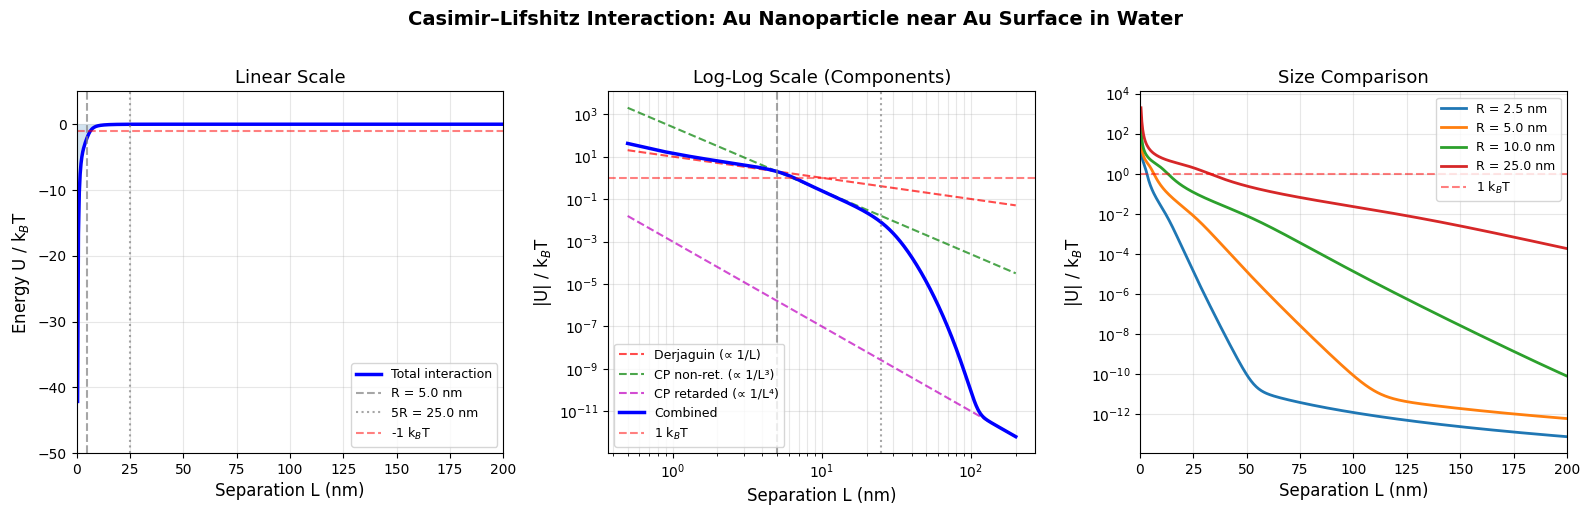


SPHERE-PLANE INTERACTION SUMMARY
Parameter                 Value                              
------------------------------------------------------------
Particle radius R:        5.0 nm
Hamaker constant A_H:     5.0 × 10⁻²⁰ J
Temperature T:            298 K
Medium:                   Water (ε = 78.5)
------------------------------------------------------------

Separation (nm)      |U|/kT          Regime                   
------------------------------------------------------------
1                    1.511e+01       Derjaguin (near-field)   
2                    6.380e+00       Derjaguin (near-field)   
5                    2.011e+00       Derjaguin (near-field)   
10                   2.470e-01       CP non-retarded          
25                   8.111e-03       CP retarded (far-field)  
50                   1.357e-05       CP retarded (far-field)  
100                  8.754e-11       CP retarded (far-field)  

------------------------------------------------------------
CHARAC

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
R = 5e-9               # Radius of Au nanoparticle (m)
A_H = 5e-20            # Hamaker constant for Au-water-Au (J)
kB = 1.38e-23          # Boltzmann constant (J/K)
T = 298                # Temperature (K)
L_values = np.linspace(0.5e-9, 200e-9, 500)  # Separation distances (m)

# Physical constants
hbar = 1.054e-34  # J*s
c = 3e8           # m/s
eps0 = 8.854e-12  # F/m
eps_m = 78.5      # Relative permittivity of water

# -----------------------------
# Functions
# -----------------------------
def U_vdW_derjaguin_sphere_plane(L):
    """
    Near-field / non-retarded vdW for sphere near plane (Derjaguin approximation)
    U(L) = -A_H * R / (6*L)
    Valid when L << R
    """
    return -A_H * R / (6 * L)

def U_CP_nonretarded_sphere_plane(L):
    """
    Non-retarded Casimir-Polder (dipole) approximation for small sphere
    U(L) ~ -A_H * R^3 / (6 * L^3)
    Valid when R << L << λ_plasma
    """
    return -A_H * R**3 / (6 * L**3)

def U_CP_retarded_sphere_plane(L):
    """
    Retarded Casimir-Polder (far-field)
    U(L) ~ -3*hbar*c*alpha / (8*pi*L^4)
    Valid when L >> λ_plasma (~100 nm)
    """
    alpha = 4 * np.pi * eps0 * eps_m * R**3
    return -3 * hbar * c * alpha / (8 * np.pi * L**4)

def smooth_transition(L, L_trans, width):
    """Smooth sigmoid transition function"""
    return 1 / (1 + np.exp(-(L - L_trans) / width))

# -----------------------------
# Compute energies with smooth transitions
# -----------------------------
U_derjaguin = np.array([U_vdW_derjaguin_sphere_plane(L) for L in L_values])
U_CP_nr = np.array([U_CP_nonretarded_sphere_plane(L) for L in L_values])
U_CP_ret = np.array([U_CP_retarded_sphere_plane(L) for L in L_values])

# Transition points and widths
L_trans1 = R          # Derjaguin to non-retarded CP
L_trans2 = 5 * R      # Non-retarded to retarded CP
width1 = R / 5
width2 = R

# Smooth transitions
trans1 = smooth_transition(L_values, L_trans1, width1)
trans2 = smooth_transition(L_values, L_trans2, width2)

# Combined potential with smooth blending
U = (1 - trans1) * U_derjaguin + \
    trans1 * (1 - trans2) * U_CP_nr + \
    trans2 * U_CP_ret

# Convert to kBT units
U_kBT = U / (kB * T)
U_derjaguin_kBT = U_derjaguin / (kB * T)
U_CP_nr_kBT = U_CP_nr / (kB * T)
U_CP_ret_kBT = U_CP_ret / (kB * T)

# -----------------------------
# Plot - Three panel figure
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Linear scale
ax1 = axes[0]
ax1.plot(L_values*1e9, U_kBT, 'b-', linewidth=2.5, label='Total interaction')
ax1.axvline(R*1e9, color='gray', linestyle='--', alpha=0.7, label=f'R = {R*1e9:.1f} nm')
ax1.axvline(5*R*1e9, color='gray', linestyle=':', alpha=0.7, label=f'5R = {5*R*1e9:.1f} nm')
ax1.axhline(-1, color='red', linestyle='--', alpha=0.5, label='-1 k$_B$T')
ax1.fill_between(L_values*1e9, U_kBT, alpha=0.2)
ax1.set_xlabel('Separation L (nm)', fontsize=12)
ax1.set_ylabel('Energy U / k$_B$T', fontsize=12)
ax1.set_title('Linear Scale', fontsize=13)
ax1.set_ylim([min(-50, np.min(U_kBT)*1.1), 5])
ax1.set_xlim([0, L_values[-1]*1e9])
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right', fontsize=9)

# Panel 2: Log-log scale with individual components
ax2 = axes[1]
ax2.loglog(L_values*1e9, np.abs(U_derjaguin_kBT), 'r--', linewidth=1.5, 
           alpha=0.7, label='Derjaguin (∝ 1/L)')
ax2.loglog(L_values*1e9, np.abs(U_CP_nr_kBT), 'g--', linewidth=1.5, 
           alpha=0.7, label='CP non-ret. (∝ 1/L³)')
ax2.loglog(L_values*1e9, np.abs(U_CP_ret_kBT), 'm--', linewidth=1.5, 
           alpha=0.7, label='CP retarded (∝ 1/L⁴)')
ax2.loglog(L_values*1e9, np.abs(U_kBT), 'b-', linewidth=2.5, label='Combined')
ax2.axvline(R*1e9, color='gray', linestyle='--', alpha=0.7)
ax2.axvline(5*R*1e9, color='gray', linestyle=':', alpha=0.7)
ax2.axhline(1, color='red', linestyle='--', alpha=0.5, label='1 k$_B$T')
ax2.set_xlabel('Separation L (nm)', fontsize=12)
ax2.set_ylabel('|U| / k$_B$T', fontsize=12)
ax2.set_title('Log-Log Scale (Components)', fontsize=13)
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(loc='lower left', fontsize=9)

# Panel 3: Compare different particle sizes
ax3 = axes[2]
R_sizes = [2.5e-9, 5e-9, 10e-9, 25e-9]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for R_i, color in zip(R_sizes, colors):
    # Recalculate for each size
    U_derj_i = -A_H * R_i / (6 * L_values)
    U_CP_nr_i = -A_H * R_i**3 / (6 * L_values**3)
    alpha_i = 4 * np.pi * eps0 * eps_m * R_i**3
    U_CP_ret_i = -3 * hbar * c * alpha_i / (8 * np.pi * L_values**4)
    
    trans1_i = smooth_transition(L_values, R_i, R_i/5)
    trans2_i = smooth_transition(L_values, 5*R_i, R_i)
    
    U_i = (1 - trans1_i) * U_derj_i + \
          trans1_i * (1 - trans2_i) * U_CP_nr_i + \
          trans2_i * U_CP_ret_i
    
    U_i_kBT = U_i / (kB * T)
    ax3.semilogy(L_values*1e9, np.abs(U_i_kBT), '-', linewidth=2, 
                 color=color, label=f'R = {R_i*1e9:.1f} nm')

ax3.axhline(1, color='red', linestyle='--', alpha=0.5, label='1 k$_B$T')
ax3.set_xlabel('Separation L (nm)', fontsize=12)
ax3.set_ylabel('|U| / k$_B$T', fontsize=12)
ax3.set_title('Size Comparison', fontsize=13)
ax3.set_xlim([0, L_values[-1]*1e9])
ax3.grid(True, alpha=0.3, which='both')
ax3.legend(loc='upper right', fontsize=9)

plt.suptitle(f'Casimir–Lifshitz Interaction: Au Nanoparticle near Au Surface in Water', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sphere_plane_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------
# Print summary table
# -----------------------------
print("\n" + "="*60)
print("SPHERE-PLANE INTERACTION SUMMARY")
print("="*60)
print(f"{'Parameter':<25} {'Value':<35}")
print("-"*60)
print(f"{'Particle radius R:':<25} {R*1e9:.1f} nm")
print(f"{'Hamaker constant A_H:':<25} {A_H*1e20:.1f} × 10⁻²⁰ J")
print(f"{'Temperature T:':<25} {T} K")
print(f"{'Medium:':<25} Water (ε = {eps_m})")
print("-"*60)
print(f"\n{'Separation (nm)':<20} {'|U|/kT':<15} {'Regime':<25}")
print("-"*60)

test_distances = [1, 2, 5, 10, 25, 50, 100, 200]
for d in test_distances:
    if d*1e-9 <= L_values[-1]:
        U_val = np.interp(d, L_values*1e9, np.abs(U_kBT))
        if d*1e-9 <= R:
            regime = "Derjaguin (near-field)"
        elif d*1e-9 <= 5*R:
            regime = "CP non-retarded"
        else:
            regime = "CP retarded (far-field)"
        print(f"{d:<20} {U_val:<15.3e} {regime:<25}")

# -----------------------------
# Characteristic lengths
# -----------------------------
print("\n" + "-"*60)
print("CHARACTERISTIC LENGTHS")
print("-"*60)
print(f"Particle radius R:           {R*1e9:.1f} nm")
print(f"Near-field cutoff (R):       {R*1e9:.1f} nm")
print(f"Retardation onset (5R):      {5*R*1e9:.1f} nm")
print(f"Plasma wavelength (~Au):     ~137 nm")

# Find distance where U = 1 kT
idx_1kT = np.argmin(np.abs(np.abs(U_kBT) - 1))
L_1kT = L_values[idx_1kT] * 1e9
print(f"\nDistance where |U| = 1 kT:   {L_1kT:.1f} nm")

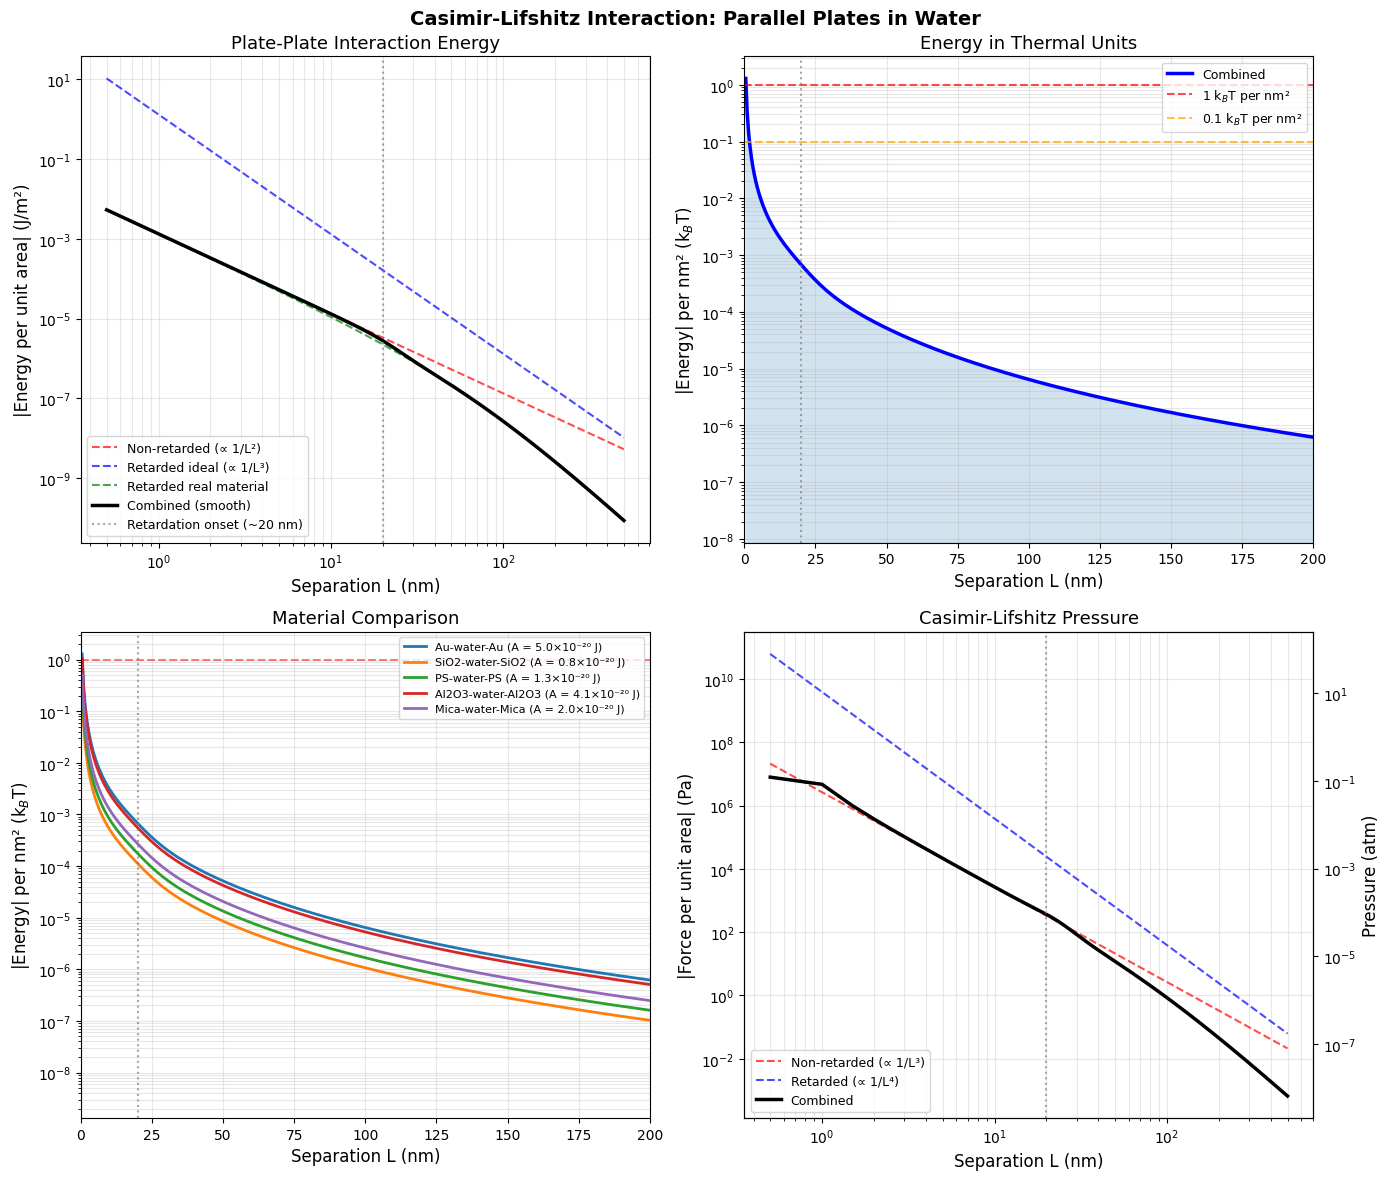

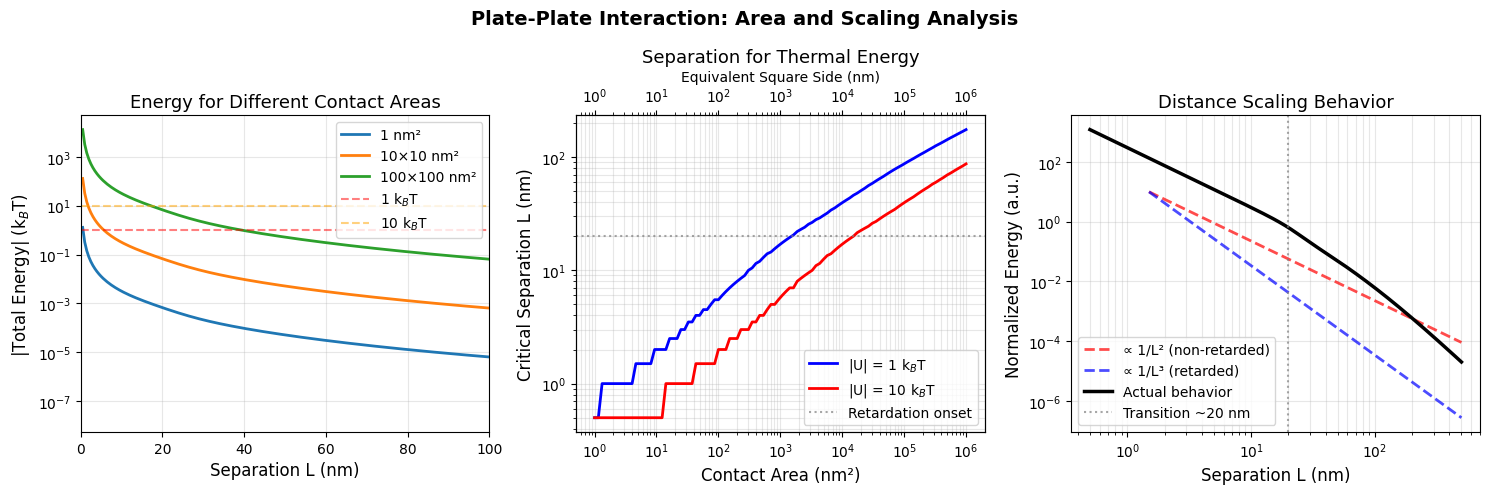

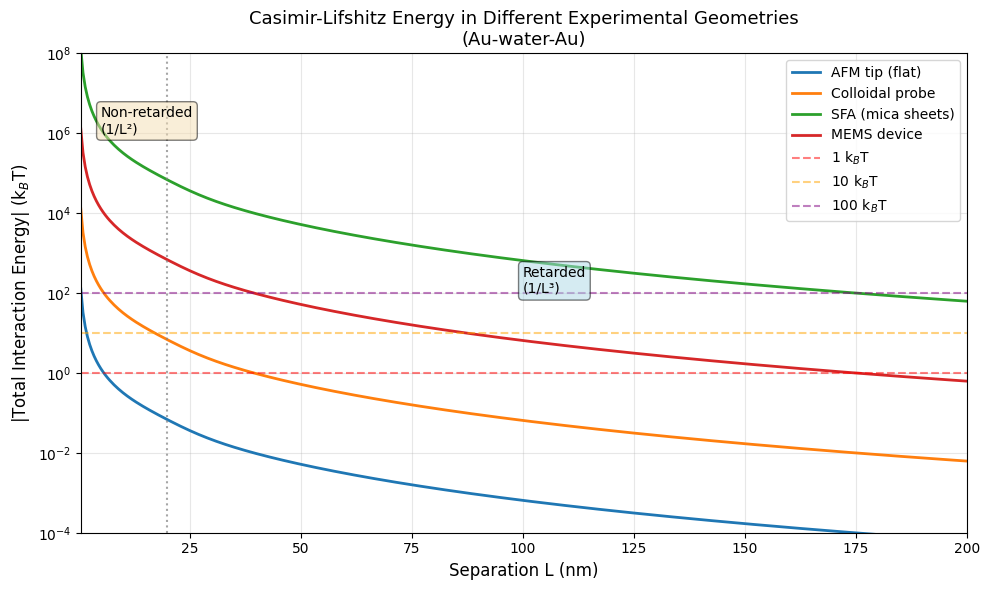


PLATE-PLATE CASIMIR-LIFSHITZ INTERACTION SUMMARY

--- PHYSICS OVERVIEW ---

For two parallel infinite plates separated by distance L:

NON-RETARDED (L << λ_plasma ≈ 100 nm):
  Energy per unit area: u(L) = -A_H / (12πL²)
  Force per unit area:  F(L) = -A_H / (6πL³)

RETARDED (L >> λ_plasma):
  Energy per unit area: u(L) = -π²ħc / (240L³)  [ideal conductors]
  Force per unit area:  F(L) = -π²ħc / (80L⁴)

TRANSITION: ~20-100 nm depending on material


--- MATERIAL PROPERTIES ---
Material                  A_H (×10⁻²⁰ J)       u at 1nm (mJ/m²)    
-----------------------------------------------------------------
Au-water-Au               5.00                 1.326               
SiO2-water-SiO2           0.83                 0.220               
PS-water-PS               1.30                 0.345               
Al2O3-water-Al2O3         4.10                 1.088               
Mica-water-Mica           2.00                 0.531               

--- ENERGY VALUES (Au-water-Au) ---
Separat

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
A_H_values = {
    'Au-water-Au': 5e-20,
    'SiO2-water-SiO2': 0.83e-20,
    'PS-water-PS': 1.3e-20,
    'Al2O3-water-Al2O3': 4.1e-20,
    'Mica-water-Mica': 2.0e-20
}
A_H_default = 5e-20     # Default: Au-water-Au (J)

kB = 1.38e-23           # Boltzmann constant (J/K)
T = 298                 # Temperature (K)
L_values = np.linspace(0.5e-9, 500e-9, 1000)  # Separation distances (m)

# Physical constants
hbar = 1.054e-34        # Reduced Planck constant (J*s)
c = 3e8                 # Speed of light (m/s)

# Reference areas
area_1nm2 = 1e-18       # 1 nm² in m²
area_10nm2 = 1e-16      # 10 nm × 10 nm in m²
area_100nm2 = 1e-14     # 100 nm × 100 nm in m²

# Retardation transition distance (approximate)
L_retard = 20e-9        # ~20 nm for most materials

# -----------------------------
# Functions
# -----------------------------
def U_vdW_plate_plate(L, A_H):
    """
    Non-retarded van der Waals / Lifshitz energy per unit area for plate–plate
    u(L) = -A_H / (12*π*L²)
    Valid for L << λ_plasma (~100 nm)
    """
    return -A_H / (12 * np.pi * L**2)

def U_retarded_plate_plate(L, A_H):
    """
    Retarded Casimir-Lifshitz energy per unit area (far-field)
    u(L) = -π²ħc / (240*L³)
    This is the ideal conductor limit; real materials have reduced coefficient
    For real materials: u(L) ≈ -A_H*c / (L³) with material-dependent prefactor
    """
    # Ideal conductor (maximum) limit
    return -(np.pi**2 * hbar * c) / (240 * L**3)

def U_retarded_real_material(L, A_H):
    """
    Approximate retarded interaction for real materials
    Uses interpolation between non-retarded and fully retarded regimes
    """
    # Characteristic length scale
    lambda_char = 100e-9  # ~100 nm characteristic wavelength
    
    # Retardation function (Casimir-Polder style correction)
    p = L / lambda_char
    f_ret = 1 / (1 + 2*p + 2*p**2)  # Approximate retardation factor
    
    return -A_H * f_ret / (12 * np.pi * L**2)

def smooth_transition(L, L_trans, width):
    """Smooth sigmoid transition function"""
    return 1 / (1 + np.exp(-(L - L_trans) / width))

def compute_plate_energy(L_array, A_H, use_smooth=True):
    """
    Compute plate-plate interaction with smooth transition
    """
    U_nr = U_vdW_plate_plate(L_array, A_H)
    U_ret = U_retarded_plate_plate(L_array, A_H)
    U_real = U_retarded_real_material(L_array, A_H)
    
    if use_smooth:
        # Smooth transition around retardation onset
        trans = smooth_transition(L_array, L_retard, L_retard/5)
        U_combined = (1 - trans) * U_nr + trans * U_real
    else:
        # Sharp transition
        U_combined = np.where(L_array <= L_retard, U_nr, U_ret)
    
    return U_combined, U_nr, U_ret, U_real

# -----------------------------
# Compute energies for default material
# -----------------------------
U_combined, U_nr, U_ret, U_real = compute_plate_energy(L_values, A_H_default)

# Convert to different unit representations
U_J_per_m2 = U_combined                           # J/m²
U_kBT_per_nm2 = U_combined * area_1nm2 / (kB * T)  # kT per nm²
U_mJ_per_m2 = U_combined * 1e3                    # mJ/m²

# -----------------------------
# Plot 1: Main four-panel figure
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Panel 1: Energy per unit area (log-log scale)
ax1 = axes[0, 0]
ax1.loglog(L_values*1e9, np.abs(U_nr), 'r--', linewidth=1.5, 
           alpha=0.7, label='Non-retarded (∝ 1/L²)')
ax1.loglog(L_values*1e9, np.abs(U_ret), 'b--', linewidth=1.5, 
           alpha=0.7, label='Retarded ideal (∝ 1/L³)')
ax1.loglog(L_values*1e9, np.abs(U_real), 'g--', linewidth=1.5, 
           alpha=0.7, label='Retarded real material')
ax1.loglog(L_values*1e9, np.abs(U_combined), 'k-', linewidth=2.5, 
           label='Combined (smooth)')
ax1.axvline(L_retard*1e9, color='gray', linestyle=':', alpha=0.7, 
            label=f'Retardation onset (~{L_retard*1e9:.0f} nm)')
ax1.set_xlabel('Separation L (nm)', fontsize=12)
ax1.set_ylabel('|Energy per unit area| (J/m²)', fontsize=12)
ax1.set_title('Plate-Plate Interaction Energy', fontsize=13)
ax1.grid(True, alpha=0.3, which='both')
ax1.legend(loc='lower left', fontsize=9)

# Panel 2: Energy in kT per nm² (practical units)
ax2 = axes[0, 1]
U_nr_kBT = np.abs(U_nr) * area_1nm2 / (kB * T)
U_ret_kBT = np.abs(U_ret) * area_1nm2 / (kB * T)
U_combined_kBT = np.abs(U_combined) * area_1nm2 / (kB * T)

ax2.semilogy(L_values*1e9, U_combined_kBT, 'b-', linewidth=2.5, label='Combined')
ax2.axhline(1, color='red', linestyle='--', alpha=0.7, label='1 k$_B$T per nm²')
ax2.axhline(0.1, color='orange', linestyle='--', alpha=0.7, label='0.1 k$_B$T per nm²')
ax2.axvline(L_retard*1e9, color='gray', linestyle=':', alpha=0.7)
ax2.fill_between(L_values*1e9, U_combined_kBT, alpha=0.2)
ax2.set_xlabel('Separation L (nm)', fontsize=12)
ax2.set_ylabel('|Energy| per nm² (k$_B$T)', fontsize=12)
ax2.set_title('Energy in Thermal Units', fontsize=13)
ax2.set_xlim([0, 200])
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(loc='upper right', fontsize=9)

# Panel 3: Compare different materials
ax3 = axes[1, 0]
colors_mat = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for (material, A_H), color in zip(A_H_values.items(), colors_mat):
    U_mat, _, _, _ = compute_plate_energy(L_values, A_H)
    U_mat_kBT = np.abs(U_mat) * area_1nm2 / (kB * T)
    ax3.semilogy(L_values*1e9, U_mat_kBT, '-', linewidth=2, color=color, 
                 label=f'{material} (A = {A_H*1e20:.1f}×10⁻²⁰ J)')

ax3.axhline(1, color='red', linestyle='--', alpha=0.5)
ax3.axvline(L_retard*1e9, color='gray', linestyle=':', alpha=0.7)
ax3.set_xlabel('Separation L (nm)', fontsize=12)
ax3.set_ylabel('|Energy| per nm² (k$_B$T)', fontsize=12)
ax3.set_title('Material Comparison', fontsize=13)
ax3.set_xlim([0, 200])
ax3.grid(True, alpha=0.3, which='both')
ax3.legend(loc='upper right', fontsize=8)

# Panel 4: Force per unit area (pressure)
ax4 = axes[1, 1]

def F_vdW_plate_plate(L, A_H):
    """Force per unit area = -dU/dL"""
    return -A_H / (6 * np.pi * L**3)

def F_retarded_plate_plate(L, A_H):
    """Retarded force per unit area"""
    return -(np.pi**2 * hbar * c) / (80 * L**4)

F_nr = np.abs(F_vdW_plate_plate(L_values, A_H_default))
F_ret = np.abs(F_retarded_plate_plate(L_values, A_H_default))

# Numerical derivative of combined energy
F_combined = np.abs(np.gradient(U_combined, L_values))

ax4.loglog(L_values*1e9, F_nr, 'r--', linewidth=1.5, alpha=0.7, 
           label='Non-retarded (∝ 1/L³)')
ax4.loglog(L_values*1e9, F_ret, 'b--', linewidth=1.5, alpha=0.7, 
           label='Retarded (∝ 1/L⁴)')
ax4.loglog(L_values*1e9, F_combined, 'k-', linewidth=2.5, label='Combined')
ax4.axvline(L_retard*1e9, color='gray', linestyle=':', alpha=0.7)

# Add pressure scale on right axis
ax4_right = ax4.twinx()
# Convert to atmospheres (1 atm = 101325 Pa)
F_combined_atm = F_combined / 101325
ax4_right.loglog(L_values*1e9, F_combined_atm, alpha=0)  # Invisible, just for scale
ax4_right.set_ylabel('Pressure (atm)', fontsize=12)

ax4.set_xlabel('Separation L (nm)', fontsize=12)
ax4.set_ylabel('|Force per unit area| (Pa)', fontsize=12)
ax4.set_title('Casimir-Lifshitz Pressure', fontsize=13)
ax4.grid(True, alpha=0.3, which='both')
ax4.legend(loc='lower left', fontsize=9)

plt.suptitle('Casimir-Lifshitz Interaction: Parallel Plates in Water', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plate_plate_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------
# Plot 2: Different contact areas
# -----------------------------
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))

areas = {
    '1 nm²': area_1nm2,
    '10×10 nm²': area_10nm2,
    '100×100 nm²': area_100nm2
}
colors_area = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Panel 1: Total energy for different areas
ax2_1 = axes2[0]
for (area_name, area_val), color in zip(areas.items(), colors_area):
    U_total = np.abs(U_combined) * area_val / (kB * T)
    ax2_1.semilogy(L_values*1e9, U_total, '-', linewidth=2, color=color, 
                   label=f'{area_name}')

ax2_1.axhline(1, color='red', linestyle='--', alpha=0.5, label='1 k$_B$T')
ax2_1.axhline(10, color='orange', linestyle='--', alpha=0.5, label='10 k$_B$T')
ax2_1.set_xlabel('Separation L (nm)', fontsize=12)
ax2_1.set_ylabel('|Total Energy| (k$_B$T)', fontsize=12)
ax2_1.set_title('Energy for Different Contact Areas', fontsize=13)
ax2_1.set_xlim([0, 100])
ax2_1.grid(True, alpha=0.3, which='both')
ax2_1.legend(loc='upper right', fontsize=10)

# Panel 2: Critical distance vs area
ax2_2 = axes2[1]
area_range = np.logspace(-18, -12, 100)  # 1 nm² to 1 µm²
L_crit_1kT = []
L_crit_10kT = []

for area in area_range:
    U_total_kBT = np.abs(U_combined) * area / (kB * T)
    
    # Find where U = 1 kT
    idx_1kT = np.argmin(np.abs(U_total_kBT - 1))
    L_crit_1kT.append(L_values[idx_1kT] * 1e9)
    
    # Find where U = 10 kT
    idx_10kT = np.argmin(np.abs(U_total_kBT - 10))
    L_crit_10kT.append(L_values[idx_10kT] * 1e9)

area_nm2 = area_range * 1e18  # Convert to nm²
ax2_2.loglog(area_nm2, L_crit_1kT, 'b-', linewidth=2, label='|U| = 1 k$_B$T')
ax2_2.loglog(area_nm2, L_crit_10kT, 'r-', linewidth=2, label='|U| = 10 k$_B$T')
ax2_2.axhline(L_retard*1e9, color='gray', linestyle=':', alpha=0.7, 
              label='Retardation onset')
ax2_2.set_xlabel('Contact Area (nm²)', fontsize=12)
ax2_2.set_ylabel('Critical Separation L (nm)', fontsize=12)
ax2_2.set_title('Separation for Thermal Energy', fontsize=13)
ax2_2.grid(True, alpha=0.3, which='both')
ax2_2.legend(loc='lower right', fontsize=10)

# Add secondary x-axis with equivalent square side length
ax2_2_top = ax2_2.twiny()
side_lengths = np.sqrt(area_range) * 1e9  # nm
ax2_2_top.set_xscale('log')
ax2_2_top.set_xlim(ax2_2.get_xlim())
ax2_2_top.set_xlabel('Equivalent Square Side (nm)', fontsize=10)

# Panel 3: Scaling behavior
ax2_3 = axes2[2]

# Show L² and L³ scaling
L_plot = L_values[L_values > 1e-9]
scaling_L2 = (L_plot[0] / L_plot)**2 * 10  # Normalized
scaling_L3 = (L_plot[0] / L_plot)**3 * 10  # Normalized

ax2_3.loglog(L_plot*1e9, scaling_L2, 'r--', linewidth=2, 
             alpha=0.7, label='∝ 1/L² (non-retarded)')
ax2_3.loglog(L_plot*1e9, scaling_L3, 'b--', linewidth=2, 
             alpha=0.7, label='∝ 1/L³ (retarded)')
ax2_3.loglog(L_values*1e9, np.abs(U_combined) / np.abs(U_combined[10]) * 10, 
             'k-', linewidth=2.5, label='Actual behavior')
ax2_3.axvline(L_retard*1e9, color='gray', linestyle=':', alpha=0.7,
              label=f'Transition ~{L_retard*1e9:.0f} nm')
ax2_3.set_xlabel('Separation L (nm)', fontsize=12)
ax2_3.set_ylabel('Normalized Energy (a.u.)', fontsize=12)
ax2_3.set_title('Distance Scaling Behavior', fontsize=13)
ax2_3.grid(True, alpha=0.3, which='both')
ax2_3.legend(loc='lower left', fontsize=10)

plt.suptitle('Plate-Plate Interaction: Area and Scaling Analysis', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plate_plate_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------
# Plot 3: Comparison with experimental regimes
# -----------------------------
fig3, ax3 = plt.subplots(figsize=(10, 6))

# Different experimental scenarios
scenarios = {
    'AFM tip (flat)': {'area': 100e-18, 'color': '#1f77b4'},      # ~10 nm radius flat
    'Colloidal probe': {'area': 1e-14, 'color': '#ff7f0e'},       # ~100 nm contact
    'SFA (mica sheets)': {'area': 1e-10, 'color': '#2ca02c'},     # ~10 µm contact
    'MEMS device': {'area': 1e-12, 'color': '#d62728'}            # ~1 µm contact
}

for scenario, params in scenarios.items():
    U_scenario = np.abs(U_combined) * params['area'] / (kB * T)
    ax3.semilogy(L_values*1e9, U_scenario, '-', linewidth=2, 
                 color=params['color'], label=scenario)

ax3.axhline(1, color='red', linestyle='--', alpha=0.5, label='1 k$_B$T')
ax3.axhline(10, color='orange', linestyle='--', alpha=0.5, label='10 k$_B$T')
ax3.axhline(100, color='purple', linestyle='--', alpha=0.5, label='100 k$_B$T')
ax3.axvline(L_retard*1e9, color='gray', linestyle=':', alpha=0.7)

ax3.set_xlabel('Separation L (nm)', fontsize=12)
ax3.set_ylabel('|Total Interaction Energy| (k$_B$T)', fontsize=12)
ax3.set_title('Casimir-Lifshitz Energy in Different Experimental Geometries\n(Au-water-Au)', 
              fontsize=13)
ax3.set_xlim([0.5, 200])
ax3.set_ylim([1e-4, 1e8])
ax3.grid(True, alpha=0.3, which='both')
ax3.legend(loc='upper right', fontsize=10)

# Add regime annotations
ax3.annotate('Non-retarded\n(1/L²)', xy=(5, 1e6), fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax3.annotate('Retarded\n(1/L³)', xy=(100, 1e2), fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.savefig('plate_plate_experiments.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------
# Print comprehensive summary
# -----------------------------
print("\n" + "="*80)
print("PLATE-PLATE CASIMIR-LIFSHITZ INTERACTION SUMMARY")
print("="*80)

print("\n--- PHYSICS OVERVIEW ---")
print("""
For two parallel infinite plates separated by distance L:

NON-RETARDED (L << λ_plasma ≈ 100 nm):
  Energy per unit area: u(L) = -A_H / (12πL²)
  Force per unit area:  F(L) = -A_H / (6πL³)
  
RETARDED (L >> λ_plasma):
  Energy per unit area: u(L) = -π²ħc / (240L³)  [ideal conductors]
  Force per unit area:  F(L) = -π²ħc / (80L⁴)
  
TRANSITION: ~20-100 nm depending on material
""")

print("\n--- MATERIAL PROPERTIES ---")
print(f"{'Material':<25} {'A_H (×10⁻²⁰ J)':<20} {'u at 1nm (mJ/m²)':<20}")
print("-"*65)
for material, A_H in A_H_values.items():
    u_1nm = np.abs(U_vdW_plate_plate(1e-9, A_H)) * 1e3  # mJ/m²
    print(f"{material:<25} {A_H*1e20:<20.2f} {u_1nm:<20.3f}")

print("\n--- ENERGY VALUES (Au-water-Au) ---")
print(f"{'Separation':<15} {'u (J/m²)':<15} {'u (mJ/m²)':<15} {'u per nm² (kT)':<15}")
print("-"*60)
test_L = [1e-9, 2e-9, 5e-9, 10e-9, 20e-9, 50e-9, 100e-9, 200e-9]
for L in test_L:
    u_val = np.interp(L, L_values, np.abs(U_combined))
    u_mJ = u_val * 1e3
    u_kT = u_val * area_1nm2 / (kB * T)
    print(f"{L*1e9:<15.0f} {u_val:<15.2e} {u_mJ:<15.4f} {u_kT:<15.4f}")

print("\n--- PRESSURE VALUES (Au-water-Au) ---")
print(f"{'Separation':<15} {'Pressure (Pa)':<20} {'Pressure (atm)':<20}")
print("-"*55)
for L in test_L:
    F_val = np.abs(F_vdW_plate_plate(L, A_H_default))
    F_atm = F_val / 101325
    print(f"{L*1e9:<15.0f} {F_val:<20.2e} {F_atm:<20.2e}")

print("\n--- PRACTICAL APPLICATIONS ---")
print("""
1. SURFACE FORCES APPARATUS (SFA):
   - Mica surfaces, contact area ~10-100 µm²
   - Measures forces in mN/m range
   - Resolution: ~0.1 nm in distance
   
2. ATOMIC FORCE MICROSCOPY (AFM):
   - Tip radius ~10-50 nm
   - Equivalent contact area ~100-1000 nm²
   - Can measure pN-nN forces
   
3. MEMS/NEMS DEVICES:
   - Typical gaps: 10-1000 nm
   - Contact areas: 0.1-100 µm²
   - Casimir/vdW forces can cause "stiction"
   
4. COLLOIDAL STABILITY:
   - Plate-plate approximation for flat particles
   - Important for clay minerals, graphene sheets
   - Determines aggregation behavior
""")

print("\n--- KEY DISTANCES ---")
L_1kT_1nm2 = L_values[np.argmin(np.abs(np.abs(U_combined)*area_1nm2/(kB*T) - 1))]
L_1kT_100nm2 = L_values[np.argmin(np.abs(np.abs(U_combined)*area_100nm2/(kB*T) - 1))]
print(f"Distance where U = 1 kT per 1 nm²:     {L_1kT_1nm2*1e9:.1f} nm")
print(f"Distance where U = 1 kT per 100×100 nm²: {L_1kT_100nm2*1e9:.1f} nm")
print(f"Non-retarded to retarded transition:   ~{L_retard*1e9:.0f} nm")